In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [2]:
TARGET = "Diabetes_binary"

binary_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
    "DiffWalk", "Sex"
]

ordinal_cols = [
    "GenHlth", "Age", "Education", "Income"
]

count_cols = [
    "MentHlth", "PhysHlth"
]

numeric_cols = [
    "BMI"
]

In [3]:
###Target distribution

target_counts = df[TARGET].value_counts().sort_index()
target_percent = df[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

target_summary

,Count,Percentage
Diabetes_binary,,
0.0,35346,50.0
1.0,35346,50.0


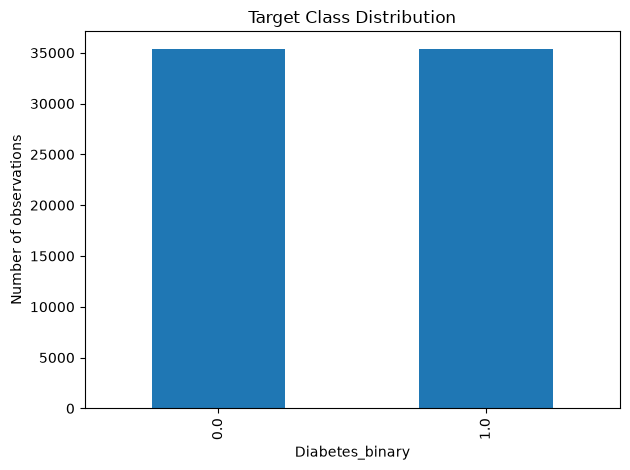

In [4]:
df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Diabetes_binary")
plt.ylabel("Number of observations")
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

In [5]:
##BMI analysis

df["BMI"].describe()

count    70692.000000
mean        29.856985
std          7.113954
min         12.000000
25%         25.000000
50%         29.000000
75%         33.000000
max         98.000000
Name: BMI, dtype: float64

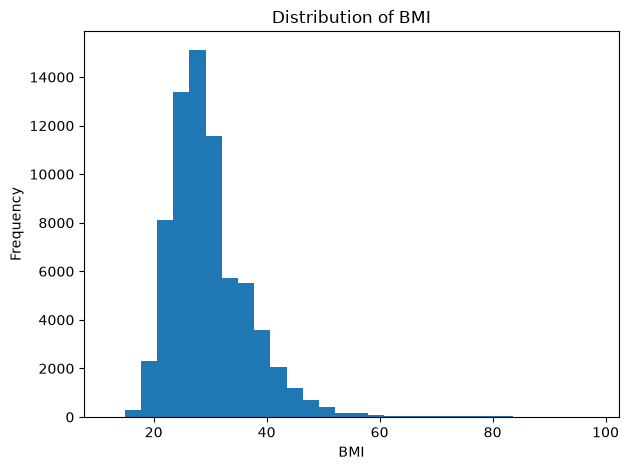

In [6]:
plt.hist(df["BMI"], bins=30)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Distribution of BMI")
plt.tight_layout()
plt.show()

In [7]:
df.groupby(TARGET)["BMI"].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0.0,35346.0,27.769960,6.187636,12.0,24.0,27.0,31.0,98.0
1.0,35346.0,31.944011,7.363401,13.0,27.0,31.0,35.0,98.0


In [8]:
##Ordinal variables


ordinal_cols = ["GenHlth", "Age", "Education", "Income"]

# Display frequency counts for all ordinal variables
for col in ordinal_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


GenHlth
GenHlth
1.0     8282
2.0    19872
3.0    23427
4.0    13303
5.0     5808
Name: count, dtype: int64

Age
Age
1.0       979
2.0      1396
3.0      2049
4.0      2793
5.0      3520
6.0      4648
7.0      6872
8.0      8603
9.0     10112
10.0    10856
11.0     8044
12.0     5394
13.0     5426
Name: count, dtype: int64

Education
Education
1.0       75
2.0     1647
3.0     3447
4.0    19473
5.0    20030
6.0    26020
Name: count, dtype: int64

Income
Income
1.0     3611
2.0     4498
3.0     5557
4.0     6658
5.0     8010
6.0    10287
7.0    11425
8.0    20646
Name: count, dtype: int64


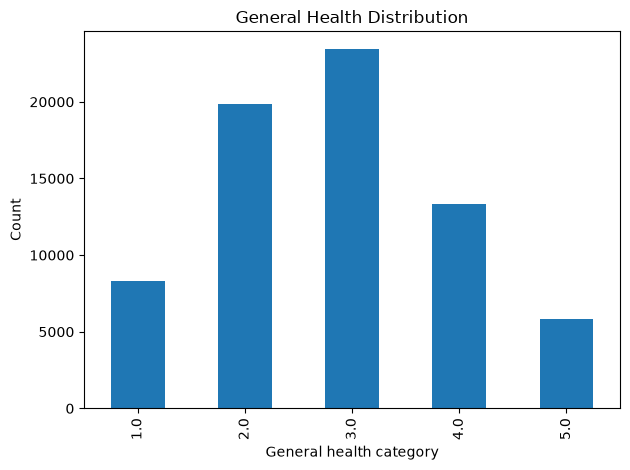

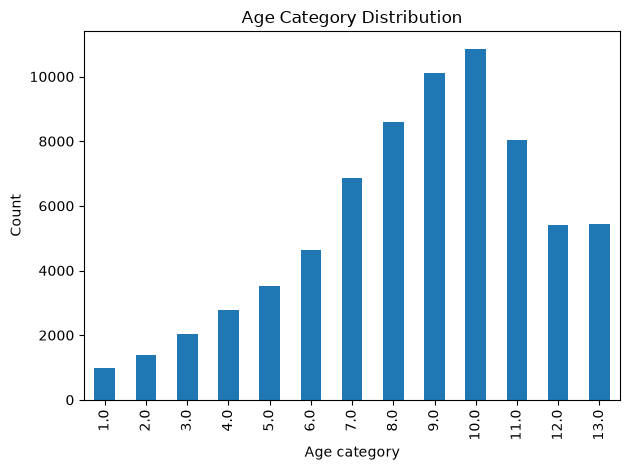

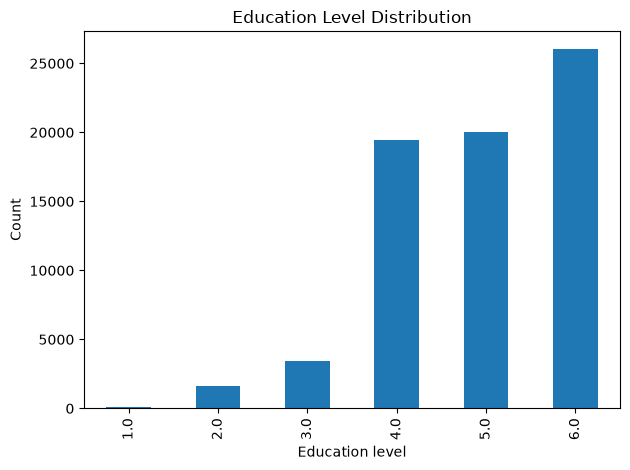

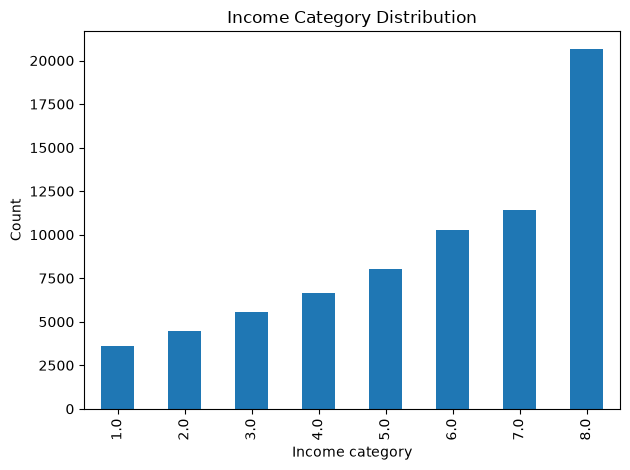

In [9]:


titles = {
    "GenHlth": "General Health Distribution",
    "Age": "Age Category Distribution",
    "Education": "Education Level Distribution",
    "Income": "Income Category Distribution"
}

xlabels = {
    "GenHlth": "General health category",
    "Age": "Age category",
    "Education": "Education level",
    "Income": "Income category"
}

for col in ordinal_cols:
    df[col].value_counts().sort_index().plot(kind="bar")

    plt.xlabel(xlabels[col])
    plt.ylabel("Count")
    plt.title(titles[col])
    plt.tight_layout()
    plt.show()

In [10]:
##Mental and physical health
df[count_cols].describe()

,MentHlth,PhysHlth
count,70692.000000,70692.000000
mean,3.752037,5.810417
std,8.155627,10.062261
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,6.000000
max,30.000000,30.000000


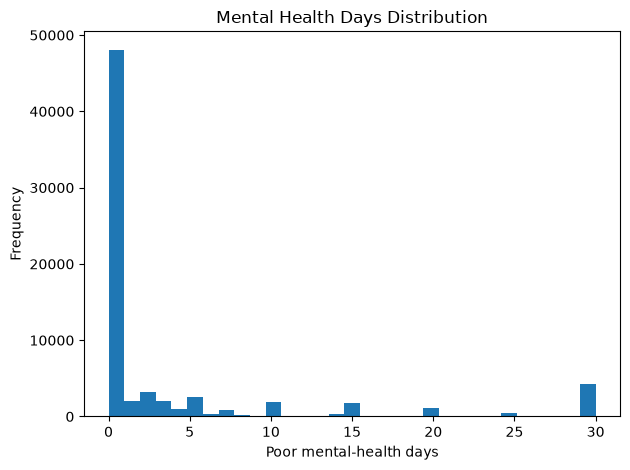

In [11]:
plt.hist(df["MentHlth"], bins=31)
plt.xlabel("Poor mental-health days")
plt.ylabel("Frequency")
plt.title("Mental Health Days Distribution")
plt.tight_layout()
plt.show()

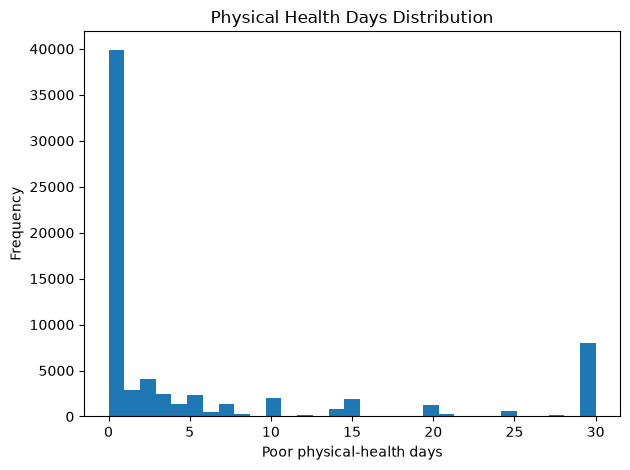

In [12]:
plt.hist(df["PhysHlth"], bins=31)
plt.xlabel("Poor physical-health days")
plt.ylabel("Frequency")
plt.title("Physical Health Days Distribution")
plt.tight_layout()
plt.show()

In [13]:
##Binary predictors
binary_prevalence = (
    df[binary_cols]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .to_frame("Percentage_1")
)

binary_prevalence

,Percentage_1
CholCheck,97.525887
AnyHealthcare,95.495954
Veggies,78.877384
PhysActivity,70.303570
Fruits,61.179483
HighBP,56.345838
HighChol,52.570305
Smoker,47.527302
Sex,45.699655
DiffWalk,25.273015


In [14]:
binary_by_target = df.groupby(TARGET)[binary_cols].mean().T * 100
binary_by_target.columns = ["Class_0_%", "Class_1_%"]
binary_by_target["Difference_pp"] = (
    binary_by_target["Class_1_%"] - binary_by_target["Class_0_%"]
)

binary_by_target.sort_values("Difference_pp", ascending=False)

,Class_0_%,Class_1_%,Difference_pp
HighBP,37.424320,75.267357,37.843037
HighChol,38.128784,67.011826,28.883042
DiffWalk,13.424433,37.121598,23.697165
HeartDiseaseorAttack,7.273808,22.288236,15.014429
Smoker,43.232615,51.821988,8.589374
Stroke,3.188480,9.245742,6.057262
Sex,43.487240,47.912069,4.424829
CholCheck,95.733605,99.318169,3.584564
NoDocbcCost,8.196118,10.586771,2.390652
AnyHealthcare,95.014995,95.976914,0.961919


In [15]:
##Ordinal/numeric variables by target
continuous_summary = df.groupby(TARGET)[
    ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]
].mean().T

continuous_summary

Diabetes_binary,0.0,1.0
BMI,27.769960,31.944011
GenHlth,2.383183,3.290981
MentHlth,3.042268,4.461806
PhysHlth,3.666355,7.954479
Age,7.789057,9.379053
Education,5.096390,4.745516
Income,6.186527,5.210094


In [16]:
corr = df.corr(numeric_only=True)

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

target_corr

GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
Income                 -0.224449
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Education              -0.170481
PhysActivity           -0.158666
Stroke                  0.125427
CholCheck               0.115382
HvyAlcoholConsump      -0.094853
MentHlth                0.087029
Smoker                  0.085999
Veggies                -0.079293
Fruits                 -0.054077
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Name: Diabetes_binary, dtype: float64

In [17]:
print("Sex")
print(df["Sex"].value_counts().sort_index())

print("\nAge")
print(df["Age"].value_counts().sort_index())

print("\nIncome")
print(df["Income"].value_counts().sort_index())

Sex
Sex
0.0    38386
1.0    32306
Name: count, dtype: int64

Age
Age
1.0       979
2.0      1396
3.0      2049
4.0      2793
5.0      3520
6.0      4648
7.0      6872
8.0      8603
9.0     10112
10.0    10856
11.0     8044
12.0     5394
13.0     5426
Name: count, dtype: int64

Income
Income
1.0     3611
2.0     4498
3.0     5557
4.0     6658
5.0     8010
6.0    10287
7.0    11425
8.0    20646
Name: count, dtype: int64


In [18]:
pd.crosstab(df["Sex"], df[TARGET])

Diabetes_binary,0.0,1.0
Sex,,
0.0,19975,18411
1.0,15371,16935


In [19]:
pd.crosstab(df["Age"], df[TARGET])

Diabetes_binary,0.0,1.0
Age,,
1.0,901,78
2.0,1256,140
3.0,1735,314
4.0,2167,626
5.0,2469,1051
6.0,2906,1742
7.0,3784,3088
8.0,4340,4263
9.0,4379,5733


In [20]:
# Sex by target
sex_target = pd.crosstab(df["Sex"], df[TARGET])
print("Sex by target")
display(sex_target)

# Age by target
age_target = pd.crosstab(df["Age"], df[TARGET])
print("Age by target")
display(age_target)

# Income by target
income_target = pd.crosstab(df["Income"], df[TARGET])
print("Income by target")
display(income_target)

Sex by target


Diabetes_binary,0.0,1.0
Sex,,
0.0,19975,18411
1.0,15371,16935


Age by target


Diabetes_binary,0.0,1.0
Age,,
1.0,901,78
2.0,1256,140
3.0,1735,314
4.0,2167,626
5.0,2469,1051
6.0,2906,1742
7.0,3784,3088
8.0,4340,4263
9.0,4379,5733


Income by target


Diabetes_binary,0.0,1.0
Income,,
1.0,1228,2383
2.0,1412,3086
3.0,1989,3568
4.0,2604,4054
5.0,3506,4504
6.0,4996,5291
7.0,6160,5265
8.0,13451,7195


In [21]:
# Row percentages within each subgroup

sex_pct = pd.crosstab(df["Sex"], df[TARGET], normalize="index") * 100
age_pct = pd.crosstab(df["Age"], df[TARGET], normalize="index") * 100
income_pct = pd.crosstab(df["Income"], df[TARGET], normalize="index") * 100

print("Sex percentages")
display(sex_pct.round(2))

print("Age percentages")
display(age_pct.round(2))

print("Income percentages")
display(income_pct.round(2))

Sex percentages


Diabetes_binary,0.0,1.0
Sex,,
0.0,52.04,47.96
1.0,47.58,52.42


Age percentages


Diabetes_binary,0.0,1.0
Age,,
1.0,92.03,7.97
2.0,89.97,10.03
3.0,84.68,15.32
4.0,77.59,22.41
5.0,70.14,29.86
6.0,62.52,37.48
7.0,55.06,44.94
8.0,50.45,49.55
9.0,43.30,56.70


Income percentages


Diabetes_binary,0.0,1.0
Income,,
1.0,34.01,65.99
2.0,31.39,68.61
3.0,35.79,64.21
4.0,39.11,60.89
5.0,43.77,56.23
6.0,48.57,51.43
7.0,53.92,46.08
8.0,65.15,34.85


In [22]:
# Duplicate profile assessment

duplicate_count = df.duplicated().sum()
duplicate_group_rows = df[df.duplicated(keep=False)].shape[0]
duplicate_pct = duplicate_count / len(df) * 100

print("Duplicated rows beyond first occurrence:", duplicate_count)
print("Rows involved in duplicate groups:", duplicate_group_rows)
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

Duplicated rows beyond first occurrence: 1635
Rows involved in duplicate groups: 2803
Duplicate percentage: 2.31%
